# 19 · PSC I형 거더 전단설계 — KDS 24 한계상태설계법

[예제 18](18_girder_design.ipynb) 에서 휨으로 설계한 **그 거더**의 전단을
검토한다. 휨에서 프리스트레스는 하중을 상쇄하는 역할이었지만,
**전단에서는 콘크리트 강도식에 직접 들어간다.**

:::{warning}
여기 쓰는 단면은 **예시이며 어떤 표준도도 아니다.**
:::

원리를 그림으로 따라가려면
[강의 L7](../lectures/L7_PSC거더_전단설계.ipynb) 을, 값을 슬라이더로 바꿔
보려면 [대화형 탐색기](../_static/explorer.html)의 L7 탭을 연다.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

**아래 코드가 하는 일** — 이 예제가 따라갈 설계 흐름을 순서도로
그린다. 각 단계 옆에 근거 조문을 적었다.

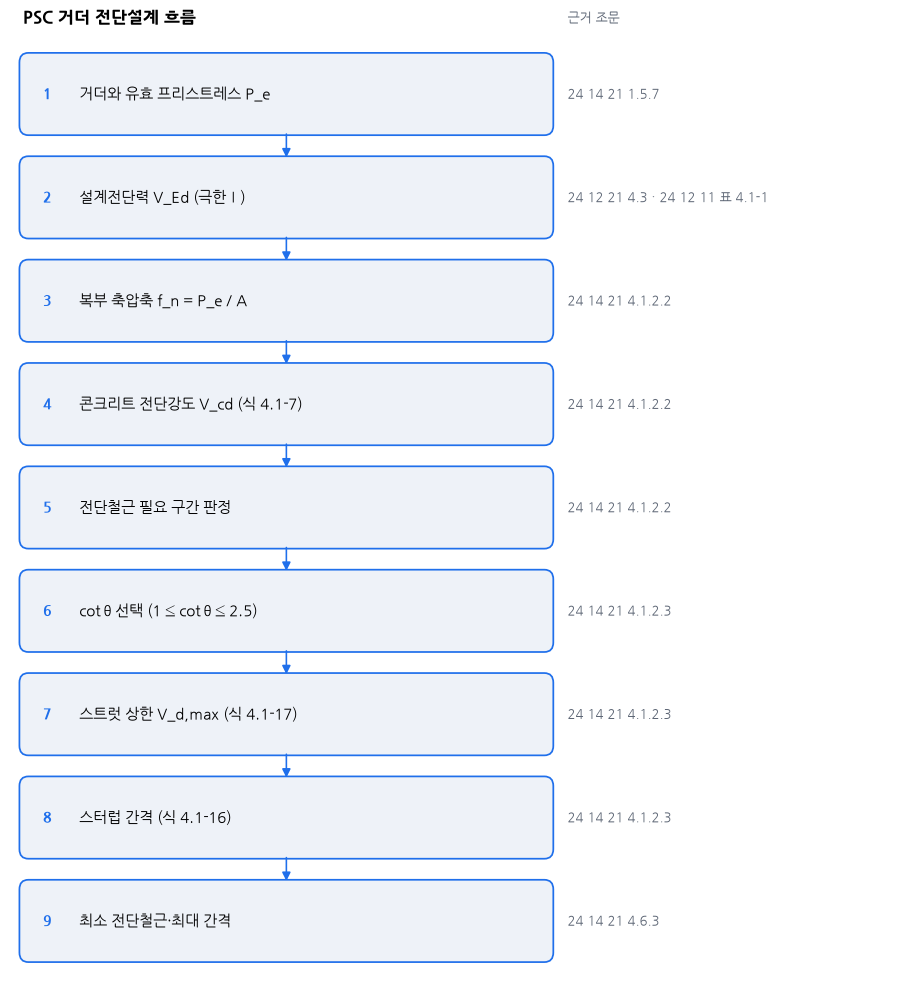

In [2]:
def _use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다.

    예제 노트북의 준비 셀은 축 라벨을 ASCII 로 두므로 글꼴을 등록하지 않는다.
    순서도는 한글을 쓰므로 여기서 직접 챙긴다.
    """
    import glob
    import sys
    from pathlib import Path

    from matplotlib import font_manager

    site = Path(sys.prefix, "lib",
                f"python{sys.version_info.major}.{sys.version_info.minor}",
                "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic"):
        if name in installed:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False


def design_flowchart(title, steps, width=9.6, box_h=0.78, gap=0.30):
    """설계 흐름을 세로 순서도로 그린다.

    Args:
        title: 그림 제목
        steps: (단계 이름, KDS 조문) 튜플의 목록. 조문에 여러 개를 적으려면
            줄바꿈 대신 쉼표로 잇는다.
        width: 그림 폭 (in)
        box_h: 상자 하나의 높이 (in 환산 전 좌표 단위)
        gap: 상자 사이 간격
    """
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

    _use_korean_font()

    n = len(steps)
    fig_h = n * (box_h + gap) + 0.7
    fig, ax = plt.subplots(figsize=(width, fig_h))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n * (box_h + gap) + 0.4)
    ax.axis("off")

    face, edge = "#eef2f8", "#1f6feb"
    for i, (name, clause) in enumerate(steps):
        y = (n - 1 - i) * (box_h + gap) + 0.2
        ax.add_patch(FancyBboxPatch(
            (0.15, y), 5.9, box_h, boxstyle="round,pad=0.04,rounding_size=0.10",
            facecolor=face, edgecolor=edge, linewidth=1.3))
        ax.text(0.42, y + box_h / 2, f"{i + 1}", va="center", ha="center",
                fontsize=10.5, color=edge, fontweight="bold")
        ax.text(0.78, y + box_h / 2, name, va="center", ha="left", fontsize=11)
        ax.text(6.25, y + box_h / 2, clause, va="center", ha="left",
                fontsize=9.5, color="#5d6675")

        if i < n - 1:
            ax.add_patch(FancyArrowPatch(
                (3.1, y), (3.1, y - gap),
                arrowstyle="-|>", mutation_scale=13,
                color=edge, linewidth=1.2))

    ax.text(0.15, n * (box_h + gap) + 0.22, title, fontsize=12.5,
            fontweight="bold", va="bottom")
    ax.text(6.25, n * (box_h + gap) + 0.24, "근거 조문", fontsize=10,
            color="#5d6675", va="bottom")
    fig.tight_layout()
    return fig

design_flowchart(
"PSC 거더 전단설계 흐름",
[
    ("거더와 유효 프리스트레스 P_e", "24 14 21 1.5.7"),
    ("설계전단력 V_Ed (극한Ⅰ)", "24 12 21 4.3 · 24 12 11 표 4.1-1"),
    ("복부 축압축 f_n = P_e / A", "24 14 21 4.1.2.2"),
    ("콘크리트 전단강도 V_cd (식 4.1-7)", "24 14 21 4.1.2.2"),
    ("전단철근 필요 구간 판정", "24 14 21 4.1.2.2"),
    ("cot θ 선택 (1 ≤ cot θ ≤ 2.5)", "24 14 21 4.1.2.3"),
    ("스트럿 상한 V_d,max (식 4.1-17)", "24 14 21 4.1.2.3"),
    ("스터럽 간격 (식 4.1-16)", "24 14 21 4.1.2.3"),
    ("최소 전단철근·최대 간격", "24 14 21 4.6.3"),
],
)
plt.show()

In [3]:
import math

from concreteproperties_kds.kds24 import (
    COT_THETA_MAX, COT_THETA_MIN, EXAMPLE_SECTIONS, GAMMA_CONCRETE,
    axial_stress, design_concrete_shear_strength, design_girder,
    girder_live_load, max_shear_strength, maximum_stirrup_spacing,
    minimum_shear_reinforcement_ratio, required_stirrup_spacing,
    shear_reinforcement_strength,
)

SECTION = EXAMPLE_SECTIONS["PSC-I 2.0m"]
SPAN, GIRDER_SPACING, DECK_THICKNESS = 30.0, 2.5, 240.0
STRAND_AREA, N_STRAND, FCK = 138.7, 25, 40.0
W_SDL, DIST_FACTOR = 3.0, 0.6

B_W, F_VY, COT_THETA = 290.0, 400.0, 2.0
A_V = 2 * 126.7          # D13 2가닥

a_p = N_STRAND * STRAND_AREA
girder = design_girder(section=SECTION, span=SPAN,
                       girder_spacing=GIRDER_SPACING,
                       deck_thickness=DECK_THICKNESS, fck=FCK, a_p=a_p,
                       w_sdl=W_SDL, distribution_factor=DIST_FACTOR)
props, comp = SECTION.properties(), girder.composite
D_P = girder.d_p

W_TOTAL = (GAMMA_CONCRETE * props.area / 1e6
           + GAMMA_CONCRETE * GIRDER_SPACING * DECK_THICKNESS / 1000.0
           + W_SDL)

def v_ed(x):
    v_dc = W_TOTAL * (SPAN / 2 - x)
    v_ll = girder_live_load(span=SPAN, section=x).shear * DIST_FACTOR
    return 1.25 * v_dc + 1.80 * v_ll

print(f"{SECTION.name}  지간 {SPAN:.0f} m,  b_w {B_W:.0f} mm,  d_p {D_P:.0f} mm")
print(f"유효 프리스트레스 P_e = {girder.p_e / 1e3:.0f} kN "
      f"(손실 {girder.losses.total_ratio * 100:.1f} %)")

PSC-I 2.0m  지간 30 m,  b_w 290 mm,  d_p 2090 mm
유효 프리스트레스 P_e = 3948 kN (손실 20.9 %)


## ① 복부의 평균 축압축과 콘크리트 전단강도

식 $(4.1\text{-}7)$ 의 마지막 항 $0.15 f_n$ 이 핵심이다.

$$
V_{cd} = \left[ 0.85 \phi_c \kappa (\rho f_{ck})^{1/3}
+ 0.15 f_n \right] b_w d
$$

In [4]:
f_n = axial_stress(n_u=girder.p_e, a_c=comp.area, fck=FCK)
v_cd_0 = design_concrete_shear_strength(
    fck=FCK, b_w=B_W, d=D_P, a_s=a_p, f_n=0.0) / 1e3
v_cd = design_concrete_shear_strength(
    fck=FCK, b_w=B_W, d=D_P, a_s=a_p, f_n=f_n) / 1e3

print(f"P_e / A_comp = {girder.p_e / comp.area:.3f} MPa")
print(f"상한 0.2 phi_c f_ck = {0.2 * 0.65 * FCK:.2f} MPa  ->  f_n = {f_n:.3f} MPa")
print()
print(f"프리스트레스 무시  V_cd = {v_cd_0:7.1f} kN")
print(f"프리스트레스 반영  V_cd = {v_cd:7.1f} kN   ({(v_cd / v_cd_0 - 1) * 100:+.0f} %)")

P_e / A_comp = 2.790 MPa
상한 0.2 phi_c f_ck = 5.20 MPa  ->  f_n = 2.790 MPa

프리스트레스 무시  V_cd =   412.5 kN
프리스트레스 반영  V_cd =   666.1 kN   (+62 %)


**f_n 은 반드시 유효 프리스트레스로 계산한다.** 긴장력을 쓰면 손실
21 % 만큼 전단강도를 과대평가한다.

## ② 어디가 지배하는가 — 휨과 정반대

In [5]:
print(f"{'위치 (m)':>9} {'V_Ed':>10} {'V_cd':>10} {'스터럽':>9}")
for x in (0.0, 2.0, 5.0, 7.5, 10.0, 15.0):
    v = v_ed(x)
    print(f"{x:9.1f} {v:10.0f} {v_cd:10.1f} "
          f"{'필요' if v > v_cd else '불필요':>9}")

xs = np.linspace(0, SPAN / 2, 400)
vs = np.array([v_ed(float(x)) for x in xs])
idx = int(np.argmax(vs <= v_cd))
x_free = float(xs[idx]) if vs[idx] <= v_cd else None
print()
if x_free:
    print(f"x = {x_free:.1f} m 부터 계산상 스터럽이 필요 없다 "
          f"(지간의 {x_free / SPAN * 100:.0f} %).")

   위치 (m)       V_Ed       V_cd       스터럽
      0.0       1339      666.1        필요
      2.0       1183      666.1        필요
      5.0        950      666.1        필요
      7.5        757      666.1        필요
     10.0        567      666.1       불필요
     15.0        196      666.1       불필요



x = 8.7 m 부터 계산상 스터럽이 필요 없다 (지간의 29 %).


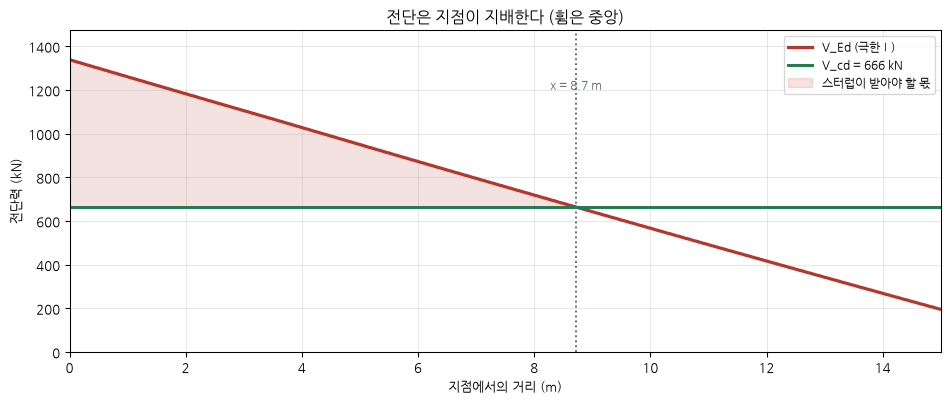

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.3))

ax.plot(xs, vs, color="#b3372c", lw=2.4, label="V_Ed (극한Ⅰ)")
ax.axhline(v_cd, color="#1f7a4d", lw=2.2, label=f"V_cd = {v_cd:.0f} kN")
ax.fill_between(xs, v_cd, vs, where=(vs > v_cd), color="#b3372c",
                alpha=0.14, label="스터럽이 받아야 할 몫")
if x_free:
    ax.axvline(x_free, color="#5b6472", ls=":", lw=1.4)
    ax.annotate(f"x = {x_free:.1f} m", (x_free, vs.max() * 0.9),
                ha="center", fontsize=9, color="#5b6472")
ax.set_xlabel("지점에서의 거리 (m)")
ax.set_ylabel("전단력 (kN)")
ax.set_title("전단은 지점이 지배한다 (휨은 중앙)")
ax.set_xlim(0, SPAN / 2)
ax.set_ylim(0, vs.max() * 1.1)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## ③ 변각 트러스 — $\cot\theta$ 의 대가

In [7]:
print(f"{'cot θ':>7} {'θ':>7} {'V_sd':>10} {'V_d,max':>10} {'지배':>10}")
rows = []
for i in range(11):
    cot = COT_THETA_MIN + (COT_THETA_MAX - COT_THETA_MIN) * i / 10
    v_sd = shear_reinforcement_strength(
        f_vy=F_VY, a_v=A_V, d=D_P, s=150.0, cot_theta=cot) / 1e3
    v_max = max_shear_strength(
        fck=FCK, b_w=B_W, d=D_P, cot_theta=cot) / 1e3
    rows.append((cot, v_sd, v_max))
    print(f"{cot:7.2f} {math.degrees(math.atan(1 / cot)):6.1f}° "
          f"{v_sd:10.0f} {v_max:10.0f} "
          f"{'스트럿' if v_sd > v_max else '스터럽':>10}")

cross = None
for a, b in zip(rows, rows[1:], strict=False):
    if (a[1] - a[2]) * (b[1] - b[2]) < 0:
        t = (a[2] - a[1]) / ((b[1] - a[1]) - (b[2] - a[2]))
        cross = a[0] + t * (b[0] - a[0])
        break
print()
if cross:
    print(f"cot θ ≈ {cross:.2f} 를 넘으면 스트럿이 먼저 깨진다.")

  cot θ       θ       V_sd    V_d,max         지배
   1.00   45.0°       1144       3574        스터럽
   1.15   41.0°       1316       3539        스터럽
   1.30   37.6°       1487       3454        스터럽
   1.45   34.6°       1659       3341        스터럽
   1.60   32.0°       1830       3213        스터럽
   1.75   29.7°       2002       3079        스터럽
   1.90   27.8°       2174       2946        스터럽
   2.05   26.0°       2345       2817        스터럽
   2.20   24.4°       2517       2693        스터럽
   2.35   23.1°       2688       2575        스트럿
   2.50   21.8°       2860       2465        스트럿

cot θ ≈ 2.29 를 넘으면 스트럿이 먼저 깨진다.


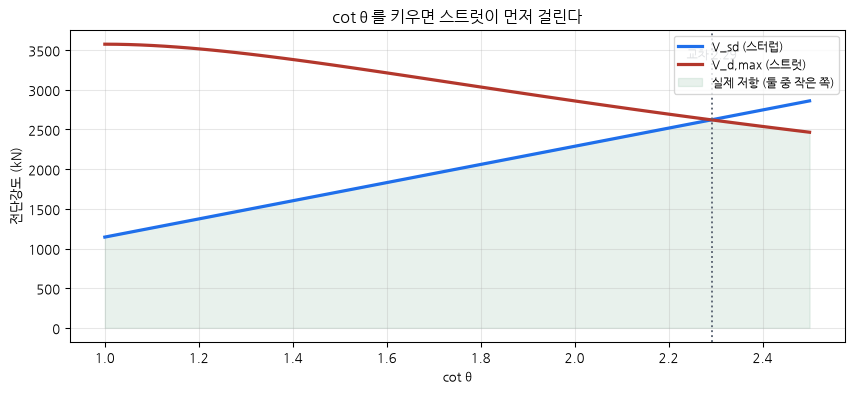

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.2))

cots = np.linspace(COT_THETA_MIN, COT_THETA_MAX, 60)
v_sd_c = [shear_reinforcement_strength(f_vy=F_VY, a_v=A_V, d=D_P,
                                       s=150.0, cot_theta=c) / 1e3
          for c in cots]
v_max_c = [max_shear_strength(fck=FCK, b_w=B_W, d=D_P,
                              cot_theta=c) / 1e3 for c in cots]

ax.plot(cots, v_sd_c, color="#1f6feb", lw=2.4, label="V_sd (스터럽)")
ax.plot(cots, v_max_c, color="#b3372c", lw=2.4, label="V_d,max (스트럿)")
ax.fill_between(cots, 0, np.minimum(v_sd_c, v_max_c), color="#1f7a4d",
                alpha=0.10, label="실제 저항 (둘 중 작은 쪽)")
if cross:
    ax.axvline(cross, color="#5b6472", ls=":", lw=1.4)
    ax.annotate(f"교차 {cross:.2f}", (cross, max(v_max_c) * 0.95),
                ha="center", fontsize=9, color="#5b6472")
ax.set_xlabel("cot θ")
ax.set_ylabel("전단강도 (kN)")
ax.set_title("cot θ 를 키우면 스트럿이 먼저 걸린다")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## ④ 스터럽 배치

In [9]:
s_max = maximum_stirrup_spacing(d=D_P)
rho_min = minimum_shear_reinforcement_ratio(fck=FCK, f_y=F_VY)
s_rho = A_V / (rho_min * B_W)
s_limit = min(s_max, s_rho)

print(f"최대 간격 0.75d      {s_max:.0f} mm")
print(f"최소 전단철근비 {rho_min * 100:.3f} %  ->  {s_rho:.0f} mm 이하")
print(f"간격 상한            {s_limit:.0f} mm")
print()
print(f"{'위치':>6} {'V_Ed':>9} {'소요 V_sd':>10} {'필요 간격':>10} {'채택':>8}")
for x in (0, 1, 2, 3, 4, 5, 7.5, 10, 15):
    v = v_ed(float(x))
    need = v - v_cd
    if need <= 0:
        print(f"{x:6.1f} {v:9.0f} {'-':>10} {'불필요':>10} {s_limit:8.0f}")
        continue
    s_req = required_stirrup_spacing(v_ed=need * 1e3, d=D_P, a_v=A_V,
                                     cot_theta=COT_THETA)
    print(f"{x:6.1f} {v:9.0f} {need:10.0f} {s_req:10.0f} "
          f"{min(s_req, s_limit):8.0f}")

최대 간격 0.75d      1568 mm
최소 전단철근비 0.126 %  ->  691 mm 이하
간격 상한            691 mm

    위치      V_Ed    소요 V_sd      필요 간격       채택
   0.0      1339        673        510      510
   1.0      1261        595        577      577
   2.0      1183        517        664      664
   3.0      1106        440        781      691
   4.0      1028        362        948      691
   5.0       950        284       1208      691
   7.5       757         91       3760      691
  10.0       567          -        불필요      691
  15.0       196          -        불필요      691


## ⑤ 왜 필요 없는 구간에도 넣는가

휨 파괴는 철근이 항복하며 처짐이 자라 **예고**가 있지만, 전단 파괴는
사인장균열이 갑자기 열리며 **예고 없이** 온다. $V_{cd}$ 식 자체가
실험의 회귀식이라 흩어짐도 크다.

> **설계의 의도** — 최소 전단철근은 강도를 위한 것이 아니라 **취성
> 파괴를 막기 위한 것**이다.

## ⑥ KDS 14 와의 대조

In [10]:
v_c_14 = 0.75 * (1 / 6) * math.sqrt(FCK) * B_W * D_P / 1e3
print(f"KDS 14 간이식  phi V_c = {v_c_14:7.1f} kN")
print(f"KDS 24  V_cd (f_n = 0) = {v_cd_0:7.1f} kN "
      f"({v_cd_0 / v_c_14 * 100:.0f} %)")
print(f"KDS 24  V_cd (반영)    = {v_cd:7.1f} kN "
      f"({v_cd / v_c_14 * 100:.0f} %)")
print()
print("프리스트레스를 빼면 KDS 24 가 보수적인데, 넣으면 뒤집힌다.")

KDS 14 간이식  phi V_c =   479.2 kN
KDS 24  V_cd (f_n = 0) =   412.5 kN (86 %)
KDS 24  V_cd (반영)    =   666.1 kN (139 %)

프리스트레스를 빼면 KDS 24 가 보수적인데, 넣으면 뒤집힌다.


(KDS 14 20 60 은 PSC 부재에 $V_{ci}$ / $V_{cw}$ 상세식을 따로 둔다.
위 비교는 간이식만 형식적으로 견준 것이다.)

## 정리

1. **프리스트레스가 전단강도에 직접 들어간다** — $V_{cd}$ 가 412 → 666 kN
   으로 **62 % 오른다.** 휨에는 없던 효과다.
2. **$f_n$ 은 유효 프리스트레스로** 계산해야 한다. 손실 21 % 를
   빠뜨리면 과대평가한다.
3. **$\cot\theta$ 는 공짜가 아니다** — 2.29 를 넘으면 스트럿이 먼저
   깨진다.
4. **전단은 지점이, 휨은 중앙이 지배한다.** 스터럽은 단부에 촘촘하다.
5. **계산상 필요 없어도 최소 전단철근은 넣는다.**